In [1]:
############################

# I primi 9 step sono identici al caso fatto girare in locale

############################

# IMPORT LIBRERIE
import numpy as np
from pathlib import Path
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import random_statevector
from qiskit.result import marginal_counts

# Il simulatore
sim = AerSimulator()

In [2]:
# SALVA IMMAGINI, riproducibilità

# Semi per la riproducibilità
SEME_STATO = 42         # stato casuale da teletrasportare
SEME_SIMULATORE = 42    # esiti casuali delle misure
N_SHOTS = 1024

# Indici dei qubit con la notazione del Capitolo 3: C -> q0, A -> q1, B -> q2
C, A, B = 0, 1, 2

# Salvataggio delle figure (in PDF, per LaTeX)
CARTELLA = Path("immagini_reali")
CARTELLA.mkdir(exist_ok=True)

def salva(fig, nome):
    fig.savefig(CARTELLA / f"{nome}.pdf", bbox_inches="tight")
    return fig

In [3]:
# Sia qc il QuantumCircuit, ossia il "contenitore" che include tutti e tre i qubit insieme a tutte le porte e le misure che applichi

# Creazione della coppia entangled di Telamon (stato di Bell):
# Si parte da |00>, si applica H, e poi CNOT, usando come control il generico a e come target b
def create_bell_pair(qc, a, b):
    qc.h(a)          # Hadamard sul primo qubit                         =>   |00> => (|0>+|1>)/sqrt(2) x |0> = (|00>+|10>)/sqrt(2)
    qc.cx(a, b)      # CNOT usando a come controllo e b come target     =>           (|00> + |11>)/sqrt(2)   =   |Phi^+_AB>

# Applicazione da parte di Alice dei Gate del protocollo di Teletrasporto Quantistico, CNOT e H, in questo ordine
def alice_gates(qc, c, a):
    qc.cx(c, a)            # CNOT da C ad A: |Psi0> -> |Psi1>
    qc.h(c)                # H su C:         |Psi1> -> |Psi2>

# Misura 
def measure_and_send(qc, c, a, m_C, m_A):
    qc.barrier()
    qc.measure(c, m_C)
    qc.measure(a, m_A)

# Operazione di BOB, I, X, Z, XZ
def bob_gates(qc, b, m_C, m_A):
    with qc.if_test((m_A, 1)):
        qc.x(b)   # X se m_A = 1
    with qc.if_test((m_C, 1)):
        qc.z(b)   # Z se m_C = 1

alpha = (0.18817375576319426+0.4634306030554158j)
beta  = (-0.6422275881713418+0.5808325393650813j)
verifica normalizzazione (deve dare ~1.0): 0.9999999999999999


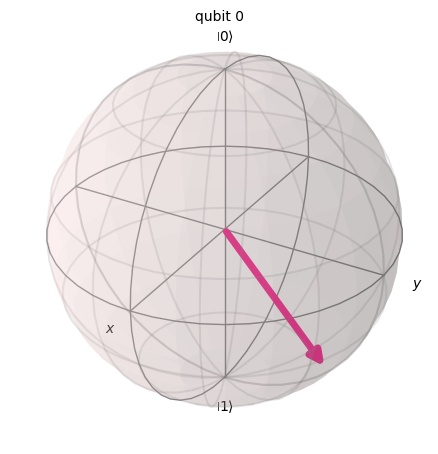

In [4]:
# SETUP
# A questo punto inizializziamo lo stato che Alice vuole teletrasportare a Bob in uno stato randomico
# Come sappiamo sulla sfera di Bloch vale: |psi> = cos(theta/2)|0> + e^{i*phi} sin(theta/2)|1>

# Stato da teletrasportare |psi_C> = alpha|0> + beta|1>, scelto a caso:

# Fissiamo alpha e beta, i coefficienti creati da random_statevector
psi = random_statevector(2, seed=SEME_STATO)
alpha, beta = psi.data
print(f"alpha = {alpha}")
print(f"beta  = {beta}")
print("verifica normalizzazione (deve dare ~1.0):", abs(alpha)**2 + abs(beta)**2)

# Siccome |alpha| = cos(theta/2), allora theta è
theta = 2 * np.arccos(abs(alpha))
# e poniamo phi come la differenza tra beta e alfa, ciò elimina la fase globale e lascia solo quella relativa 
phi = np.angle(beta) - np.angle(alpha)

plot_bloch_multivector(psi)

# Per ora abbiamo solo un vettore di numeri (nessun qubit fisico esiste
# ancora): ci servirà come "bersaglio" da confrontare alla fine, e per
# calcolare gli angoli (theta, phi) con cui costruirlo davvero su un qubit
# nello STEP 1

# NB
# Il motivo per cui, nel protocollo di teletrasporto, noi conosciamo theta e phi (mentre nella teoria che conosciamo "Alice  
# ha uno stato sconosciuto") è pratico. Vogliamo verificare che il teletrasporto funzioni e quindi dobbiamo sapere qual è lo stato bersaglio 
# da confrontare alla fine. Fisicamente, però, il punto del protocollo resta intatto: una volta che q0 è stato preparato 
# (da chiunque, con qualunque circuito), Bob riceve quello stato senza che nessuno debba mai dirgli quali sono theta e phi — 
# la correzione avviene solo sulla base dei 2 bit classici, non serve conoscere lo stato per teletrasportarlo.

#salva(plot_bloch_multivector(psi), "bloch_psi_iniziale")

In [5]:
qr = QuantumRegister(3, name="q")          # I 3 qubit vengono creati tutti insieme, in un colpo solo in questa riga => indicizzazione (0, 1, 2)
m_C = ClassicalRegister(1, name="m_C")
m_A = ClassicalRegister(1, name="m_A")
qc = QuantumCircuit(qr, m_C, m_A)


##################################

## STEP 1
# Prepariamo lo stato |psi> sul qubit di Alice (q0), partendo da |0>.
# RY porta |0> in cos(theta/2)|0> + sin(theta/2)|1> (ampiezze reali corrette);
# RZ aggiunge poi la fase relativa e^{i*phi} sulla componente |1>.
# Dopo queste due righe, q0 e' fisicamente nello stato psi.

qc.ry(theta, C)                             # applica RY al qubit di indice 0
qc.rz(phi, C)                               # applico RZ al qubit di indice 0  => ottengo allora q0 nello stato |psi>, quello che voglio teletrasportare
qc.barrier()

#################################

## STEP 2
# Telamon crea la coppia entangled di Bell (|00> + |11>) / sqrt(2)

create_bell_pair(qc, A, B)
qc.barrier()

#################################

## STEP 3
# Alice applica CNOT e H come vuole il protocollo, successivamente misura q0 e q1 
# => il collasso produce i 2 bit classici (m_C, m_A) e li invia a Bob

alice_gates(qc, C, A)
measure_and_send(qc, C, A, m_C, m_A)

#################################

## STEP 4
# Bob, sulla base dei 2 bit ricevuti, applica la correzione di Pauli
# (I, X, Z o XZ) al proprio qubit q2.
bob_gates(qc, B, m_C, m_A)

################################

## SALVA IMMAGINE
#fig2 = qc.draw('mpl', style='textbook')
#salva(fig2, "circuito_teletrasporto1")

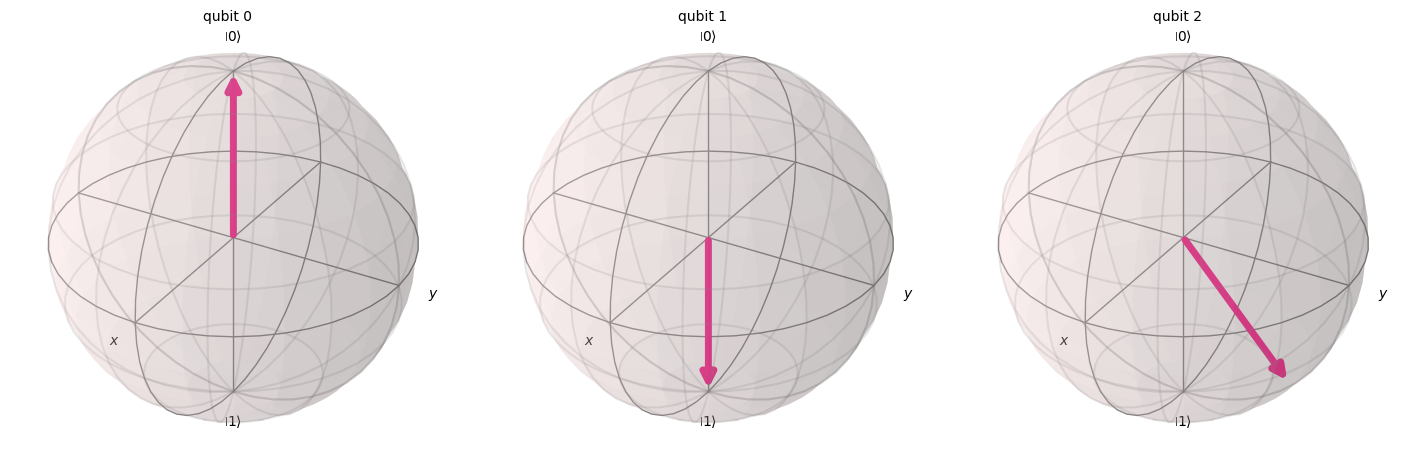

In [6]:
## STEP 5
# Verifica esatta (un singolo "shot"): eseguiamo il circuito, che include
# già una misura reale (dentro measure_and_send). 
# Quindi save_statevector() cattura lo stato completo dei 3 qubit DOPO quella misura casuale e dopo
# la correzione di Bob. Se il protocollo ha funzionato, la sfera di Bloch
# di q2 qui sotto dovrà coincidere esattamente con quella di psi (trovata nel SETUP),
# qualunque sia stato l'esito casuale della misura di Alice.

qc.save_statevector()
out_vector = sim.run(qc, seed_simulator=SEME_SIMULATORE).result().get_statevector()
plot_bloch_multivector(out_vector)

## SALVA IMMAGINE
#salva(plot_bloch_multivector(out_vector), "bloch_psi_tot")

In [7]:
## STEP 6
# Ricreiamo il circuito
# Ripetiamo quindi identici gli STEP 1-4 (preparazione, entanglement,
# misura di Bell, correzione di Bob)
qr = QuantumRegister(3, name="q")          
m_C = ClassicalRegister(1, name="m_C")
m_A = ClassicalRegister(1, name="m_A")
qc = QuantumCircuit(qr, m_C, m_A)

qc.ry(theta, C)
qc.rz(phi, C)
qc.barrier()

create_bell_pair(qc, A, B)
qc.barrier()

alice_gates(qc, C, A)
measure_and_send(qc, C, A, m_C, m_A)
bob_gates(qc, B, m_C, m_A)

####################################

## STEP 7
# A questo punto se tutto ha funzionato, q2 è esattamente nello stato psi.
# Applichiamo ora l'inverso della preparazione fatta allo STEP prima (stessi
# angoli, segno opposto, ordine invertito): se q2 era davvero psi, questa
# operazione lo riporta esattamente a |0>.

qc.rz(-phi, B)
qc.ry(-theta, B)

####################################

## STEP 8
# Aggiungiamo un terzo registro classico per leggere il risultato di q2:
# se il teletrasporto ha funzionato, la misura darà sempre 0.

cr_result = ClassicalRegister(1, name="cr_result")
qc.add_register(cr_result)
qc.measure(B, cr_result)
fig2 = qc.draw('mpl', style='textbook')

## SALVA IMMAGINE
#salva(fig2, "circuito_teletrasporto2")

In [8]:
## STEP 9
# Ripetiamo l'intero esperimento 1024 volte (1024 ripetizioni indipendenti,
# ciascuno con un esito casuale diverso della misura di Bell di Alice).
# transpile() traduce le porte di alto livello (RY, RZ, i blocchi if_test)
# nel set di gate elementari che il simulatore sa eseguire nativamente.

from qiskit.result import marginal_counts

t_qc = transpile(qc, sim)
counts = sim.run(t_qc, shots= N_SHOTS, seed_simulator=SEME_SIMULATORE).result().get_counts()
print(counts)
plot_histogram(counts)

###################################

##STEP 10
# counts contiene la distribuzione congiunta dei 3 bit classici
# (m_C, m_A, cr_result). marginal_counts isola solo cr_result (indice
# globale 2), sommando su tutti i possibili esiti di m_C/m_A: e' la
# probabilità di successo del teletrasporto, indipendentemente da quale
# dei 4 rami di Bell sia occorso in ciascuno shot.

risultato_finale = marginal_counts(counts, [2])  # indice globale 2 = cr_result
tasso_errore = 100 * risultato_finale.get('1', 0) / sum(risultato_finale.values())
print(f"Tasso di errore: {tasso_errore:.3f}%")

# viene dalla misura dei qubit: {'q2 q1 q0': n volte} = ovvero in bit classici {'cr_result m_A m_C': n volte}

{'0 0 1': 254, '0 1 0': 278, '0 0 0': 239, '0 1 1': 253}
Tasso di errore: 0.000%


In [9]:
## NEW STEP 10

def new_bob_gates(qc, a, b, c):
    qc.cx(b, c)
    qc.cz(a, c)

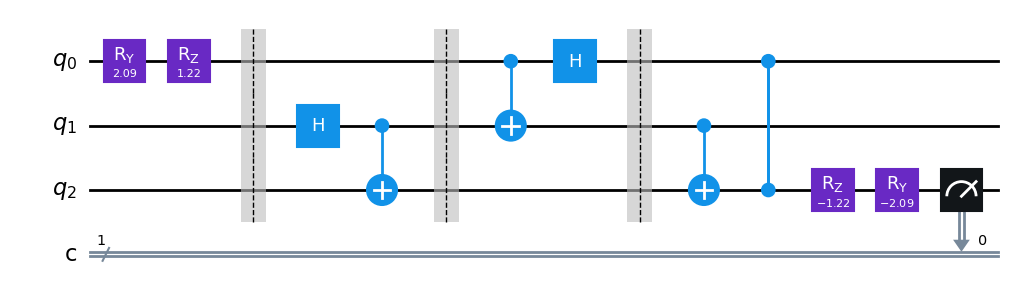

In [10]:
## NEW STEP 11
# Ricostruiamo il circuito con le stesse theta e phi trovate anche nella simulazione
qc = QuantumCircuit(3,1)

# Inizializziamo q0
qc.ry(theta, 0)      # <- al posto di qc.append(init_gate, [0])
qc.rz(phi, 0)
qc.barrier()

# Qui inizia il protocollo di teletrasporto 
create_bell_pair(qc, 1, 2)
qc.barrier()
# Send q1 to Alice and q2 to Bob
alice_gates(qc, 0, 1)
qc.barrier()

# Correzioni di Bob con la misura differita: NESSUN bit classico viene inviato              <=========== IMPORTANTE
new_bob_gates(qc, 0, 1, 2)

# Invertiamo lo stato
qc.rz(-phi, 2)       # <- al posto di qc.append(inverse_init_gate, [2])
qc.ry(-theta, 2)

# Ci interessa solo lo stato di q2
qc.measure(2,0)

# Visualizziamo il risultato e salviamo (misura differita)
display(salva(qc.draw('mpl', style='textbook'), "circuito_misura_differita"))

In [11]:
# I PROSSIMI STEP SONO SULL'Executing

## NEW STEP 12
# Al posto di IBMQ.load_account() e IBMQ.get_provider(hub='ibm-q'),
# che non esistono piu': il servizio di qiskit-ibm-runtime.

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# UNA TANTUM
#QiskitRuntimeService.save_account(
#    channel="ibm_quantum_platform",
#    token="",
#    instance="",
#    overwrite=True,
#    set_as_default=True,
#)
#print("Credenziali salvate.")

service = QiskitRuntimeService()

Processore: ibm_marrakesh - 156 qubit
Qubit fisici usati: [5, 6, 7]
q0, q1, q2 -> qubit fisici all'inizio: [7, 6, 5] - alla fine: [7, 5, 6]
Porte native: {'rz': 18, 'sx': 16, 'cz': 5, 'barrier': 3, 'measure': 1}
Profondita': 30 - porte a due qubit: 5


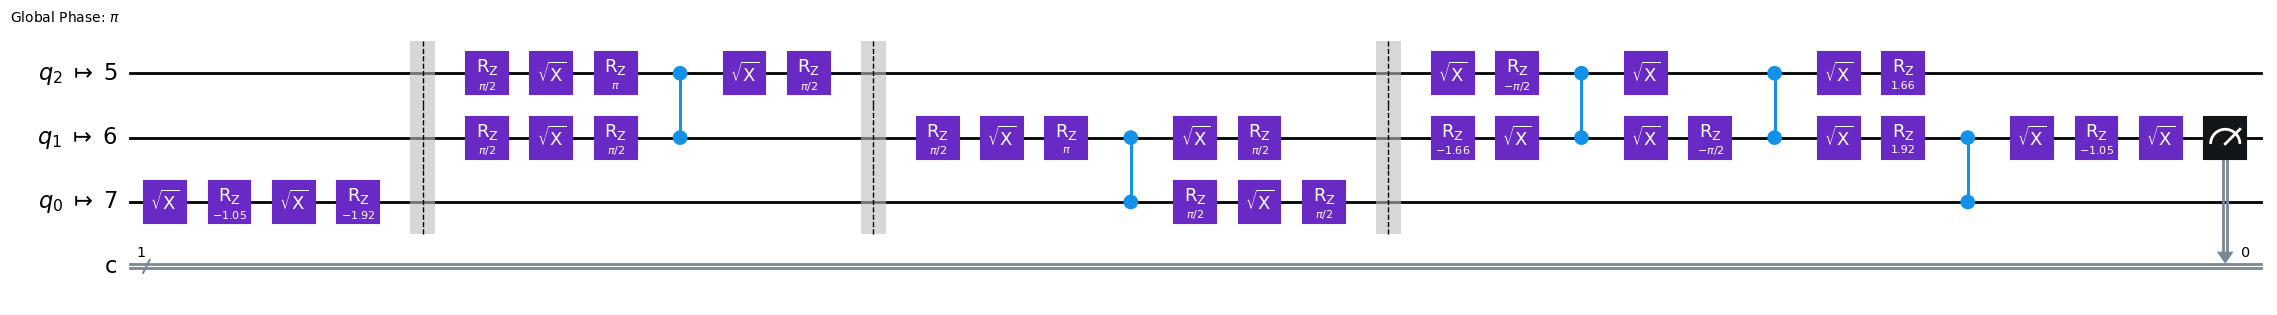

In [12]:
## NEW STEP 13
# Processore meno occupato con almeno 3 qubit
# (al posto di least_busy di qiskit.providers.ibmq, che non esiste piu')
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=3)
print("Processore:", backend.name, "-", backend.num_qubits, "qubit")

# Come nel Textbook: traspiliamo il circuito per il processore scelto.
# seed_transpiler rende riproducibile la scelta dei qubit fisici.
t_qc = transpile(qc, backend, optimization_level=3, seed_transpiler=42)

# Su quali qubit fisici e' finito il circuito
qubit_usati = sorted({t_qc.find_bit(q).index
                      for istr in t_qc.data if istr.operation.name != "barrier"
                      for q in istr.qubits})
try:
    layout_iniziale = t_qc.layout.initial_index_layout(filter_ancillas=True)
    layout_finale = t_qc.layout.final_index_layout(filter_ancillas=True)
except Exception as e:
    layout_iniziale = layout_finale = None
    print("Layout non disponibile:", e)

porte = {nome: int(n) for nome, n in t_qc.count_ops().items()}
n_porte_2q = sum(1 for istr in t_qc.data
                 if istr.operation.name != "barrier" and istr.operation.num_qubits == 2)

print("Qubit fisici usati:", qubit_usati)
print("q0, q1, q2 -> qubit fisici all'inizio:", layout_iniziale, "- alla fine:", layout_finale)
print("Porte native:", porte)
print("Profondita':", t_qc.depth(), "- porte a due qubit:", n_porte_2q)

display(salva(t_qc.draw('mpl', idle_wires=False, style='textbook', fold=-1), "circuito_traspilato"))

# A COSA SERVE IL TRANSPILE:
# 1) Traduce nelle porte native. Ogni processore sa eseguire fisicamente solo poche porte. Tutte le altre vanno scomposte in 
#    quelle che il processore sa eseguire. 
# 2) Sceglie i qubit fisici. I tuoi q0, q1 e q2 sono qubit logici. Il transpiler decide su quali qubit
#    del chip farli girare, per esempio q0 lo abbina al qubit 45, q1 al 46, q2 al 47, cercando quelli con gli errori più bassi.
# 3) Ottimizza. Fonde infatti rotazioni consecutive ed elimina porte che si annullano.
# 4) Rispetta la connettività. Sul chip una porta a due qubit si può applicare solo tra qubit fisicamente collegati. 
#    Se il circuito richiede un'interazione tra qubit non vicini, il transpiler inserisce delle SWAP per avvicinarli. 
#    Nel circuito che abbiamo creato le interazioni sono A–B (coppia di Bell), C–A (Alice gate), A–B (new bob gate, prima riga 
#    => CNOT) e C–B (seconda riga CZ), quindi tutti e tre i qubit interagiscono tra loro. 

In [13]:
# NEW STEP 14

# Calibrazioni dichiarate da IBM per i qubit usati, lette subito prima dell'esecuzione.
# NB: la temperatura del criostato NON e' fornita dall'API di IBM Quantum.
import json
import platform
from datetime import datetime, timezone
import qiskit, qiskit_aer, qiskit_ibm_runtime
from qiskit import qpy

CARTELLA_DATI = Path("risultati_reali")
CARTELLA_DATI.mkdir(exist_ok=True)

def salva_json(dati, nome):
    with open(CARTELLA_DATI / f"{nome}.json", "w") as f:
        json.dump(dati, f, indent=2, default=str)

def fmt(x, cifre=3):
    return "n.d." if x is None else f"{x:.{cifre}g}"

target = backend.target

def calibrazione_qubit(q):
    qp = target.qubit_properties[q] if target.qubit_properties else None
    mis = target["measure"].get((q,)) if "measure" in target.operation_names else None
    return {
        "qubit_fisico": q,
        "T1_us": qp.t1 * 1e6 if qp is not None and qp.t1 is not None else None,
        "T2_us": qp.t2 * 1e6 if qp is not None and qp.t2 is not None else None,
        "frequenza_GHz": qp.frequency / 1e9 if qp is not None and qp.frequency is not None else None,
        "errore_lettura": mis.error if mis is not None else None,
        "durata_lettura_ns": mis.duration * 1e9 if mis is not None and mis.duration is not None else None,
    }

def errori_porte(qubit):
    """Errore e durata di ogni porta nativa che agisce solo sui qubit indicati."""
    risultato = []
    for nome in target.operation_names:
        if nome in ("measure", "delay", "reset"):
            continue
        for qargs, prop in target[nome].items():
            if qargs is None or prop is None or not set(qargs) <= set(qubit):
                continue
            risultato.append({"porta": nome, "qubit": list(qargs), "errore": prop.error,
                              "durata_ns": prop.duration * 1e9 if prop.duration is not None else None})
    return risultato

cal_qubit = [calibrazione_qubit(q) for q in qubit_usati]
cal_porte = errori_porte(qubit_usati)

print(f"{'qubit':>6} {'T1 [us]':>9} {'T2 [us]':>9} {'f [GHz]':>8} {'err. lettura':>13}")
for c in cal_qubit:
    print(f"{c['qubit_fisico']:>6} {fmt(c['T1_us']):>9} {fmt(c['T2_us']):>9} "
          f"{fmt(c['frequenza_GHz'], 4):>8} {fmt(c['errore_lettura']):>13}")
print()
for p in cal_porte:
    print(f"{p['porta']:>6} su {str(p['qubit']):>10}: errore {fmt(p['errore'])}, durata {fmt(p['durata_ns'])} ns")

# Copia completa delle proprieta' del processore (tutti i qubit), se disponibile
try:
    salva_json(backend.properties().to_dict(), f"proprieta_complete_{backend.name}")
    print("\nProprieta' complete del processore salvate.")
except Exception as e:
    print("\nbackend.properties() non disponibile:", e)

# Tutto cio' che descrive l'esperimento, in un unico dizionario
dati_esperimento = {
    "backend": backend.name,
    "istante_calibrazione_utc": datetime.now(timezone.utc).isoformat(),
    "versioni": {"python": platform.python_version(), "qiskit": qiskit.__version__,
                 "qiskit_aer": qiskit_aer.__version__,
                 "qiskit_ibm_runtime": qiskit_ibm_runtime.__version__},
    "stato": {"alpha": [alpha.real, alpha.imag], "beta": [beta.real, beta.imag],
              "theta_rad": theta, "phi_rad": phi},
    "qubit_fisici_usati": qubit_usati,
    "layout_iniziale_q0_q1_q2": layout_iniziale,
    "layout_finale_q0_q1_q2": layout_finale,
    "circuito_traspilato": {"porte": porte, "profondita": t_qc.depth(), "porte_2q": n_porte_2q},
    "calibrazione_qubit": cal_qubit,
    "calibrazione_porte": cal_porte,
}
print(dati_esperimento["versioni"])

 qubit   T1 [us]   T2 [us]  f [GHz]  err. lettura
     5       283       186     n.d.       0.00793
     6       272       189     n.d.        0.0033
     7       258       198     n.d.        0.0151

measure_reset_2 su        [5]: errore n.d., durata 1.92e+03 ns
measure_reset_2 su        [6]: errore n.d., durata 1.92e+03 ns
measure_reset_2 su        [7]: errore n.d., durata 1.92e+03 ns
    cz su     [5, 6]: errore 0.00136, durata 68 ns
    cz su     [6, 5]: errore 0.00136, durata 68 ns
    cz su     [6, 7]: errore 0.00224, durata 68 ns
    cz su     [7, 6]: errore 0.00224, durata 68 ns
     x su        [5]: errore 0.000223, durata 36 ns
     x su        [6]: errore 0.000199, durata 36 ns
     x su        [7]: errore 0.000687, durata 36 ns
    rz su        [5]: errore 0, durata 0 ns
    rz su        [6]: errore 0, durata 0 ns
    rz su        [7]: errore 0, durata 0 ns
measure_2 su        [5]: errore 0.0022, durata 1.88e+03 ns
measure_2 su        [6]: errore 0.00244, durata 1.88e+03 ns

In [14]:
## NEW STEP 15
# Al posto di backend.run(t_qc) e job_monitor(job), che non esistono piu':
# il circuito si esegue con la primitiva Sampler di qiskit-ibm-runtime.
# shots esplicito: backend.run usava 1024 ripetizioni per default, SamplerV2 ne usa 4096.
sampler = Sampler(mode=backend)
job = sampler.run([t_qc], shots=N_SHOTS)
JOB_ID = job.job_id()
print(f"Job ID: {JOB_ID} - stato: {job.status()}")

# Salviamo SUBITO: se il kernel si riavvia durante l'attesa in coda, i dati restano
dati_esperimento["job_id"] = JOB_ID
dati_esperimento["data_invio_utc"] = datetime.now(timezone.utc).isoformat()
dati_esperimento["shots"] = N_SHOTS
salva_json(dati_esperimento, f"esperimento_{JOB_ID}")

# Circuito logico e circuito traspilato, rileggibili con qpy.load
with open(CARTELLA_DATI / f"circuiti_{JOB_ID}.qpy", "wb") as f:
    qpy.dump([qc, t_qc], f)

Job ID: datsf4dvr3kc73em0ip0 - stato: QUEUED


{'0': 990, '1': 34}


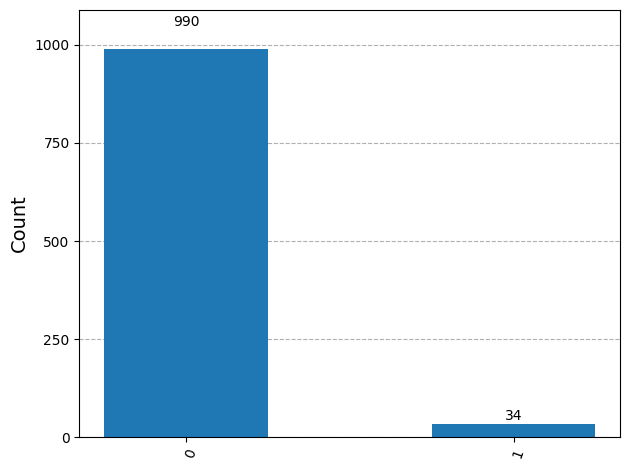

In [15]:
## NEW STEP 16
# Risultati. Se il kernel si e' riavviato: rieseguire le celle fino al NEW STEP 12
# compreso e scrivere qui l'ID del job; i dati salvati all'invio vengono ricaricati.
JOB_ID_DA_RECUPERARE = None      # None = usa il job appena inviato

if JOB_ID_DA_RECUPERARE is not None:
    JOB_ID = JOB_ID_DA_RECUPERARE
    job = service.job(JOB_ID)
    with open(CARTELLA_DATI / f"esperimento_{JOB_ID}.json") as f:
        dati_esperimento = json.load(f)

# job.result() aspetta da solo che il job finisca (al posto di job_monitor)
exp_result = job.result()
# Al posto di exp_result.get_counts(qc): il registro classico di QuantumCircuit(3, 1) si chiama "c"
exp_counts = exp_result[0].data.c.get_counts()
print(exp_counts)

display(salva(plot_histogram(exp_counts), "istogramma_reale"))

dati_esperimento["conteggi"] = exp_counts
try:
    dati_esperimento["metriche_job"] = job.metrics()     # orari di coda ed esecuzione, uso
except Exception as e:
    dati_esperimento["metriche_job"] = {"errore": str(e)}
salva_json(dati_esperimento, f"esperimento_{JOB_ID}")

In [16]:
## NEW STEP 17
# Tasso di errore come nel Textbook. .get('1', 0) evita un errore se non esce mai 1.
n_uno = exp_counts.get('1', 0)
n_tot = sum(exp_counts.values())
tasso_errore = n_uno / n_tot
print(f"L'errore sperimentale e' del: {100*tasso_errore:.3f}% ({n_uno} su {n_tot})")

dati_esperimento["esiti_1"] = n_uno
dati_esperimento["tasso_errore_sperimentale"] = tasso_errore
dati_esperimento["data_recupero_utc"] = datetime.now(timezone.utc).isoformat()
salva_json(dati_esperimento, f"esperimento_{JOB_ID}")

# Al posto di %qiskit_version_table (qiskit.tools.jupyter non esiste piu')
print(dati_esperimento["versioni"])
print("Tutto salvato in:", CARTELLA_DATI / f"esperimento_{JOB_ID}.json")

L'errore sperimentale e' del: 3.320% (34 su 1024)
{'python': '3.10.12', 'qiskit': '2.5.2', 'qiskit_aer': '0.17.2', 'qiskit_ibm_runtime': '0.49.0'}
Tutto salvato in: risultati_reali/esperimento_datsf4dvr3kc73em0ip0.json
